# Drugi domaći zadatak iz Digitalne obrade signala
## Student: Mihajlo Pavlović 2021/0343

## Deo 1.

In [1]:
USE_WIDGETS = True

import numpy as np
if USE_WIDGETS:
    %matplotlib widget
else:
    %matplotlib inline
import matplotlib as mpl
mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif', size = 18)
import matplotlib.pyplot as plt
import pickle
from scipy import signal
from scipy.signal import windows
import scipy.io as sio

from scipy.fft import fft as fft
from matplotlib.widgets import Slider

import math
from scipy.io import wavfile 

import IPython

In [2]:
#zplane
import numpy as np
import matplotlib.pyplot as plt
from  matplotlib import patches

def zplane(b, a, ax = None):
    """Plot the complex z-plane given a transfer function.
    """

    # get a figure/plot
    if ax == None:
        w, h = plt.figaspect(1)
        fig, ax = plt.subplots(1, figsize=(w, h))
        plt.subplots_adjust(left = 0.2, bottom = 0.2)

    # create the unit circle
    uc = patches.Circle((0,0), radius=1, fill=False, color='black', ls='dashed')
    ax.add_patch(uc)
        
    # Get the poles and zeros
    p = np.roots(a)
    z = np.roots(b)
    k = b[0]/a[0]
    
    ## Count same poles/zeros
    # Make poles and zeros dictionaries
    poleCounts = {}
    for i in range(len(p)):
        if p[i].imag < 0:
            key = f'%f-%fj' % (p[i].real, -p[i].imag)
        else:
            key = f'%f+%fj' % (p[i].real, p[i].imag)
        if key in poleCounts:
            poleCounts[key] += 1
        else:
            poleCounts[key] = 1
    zeroCounts = {}
    
    for i in range(len(z)):
        if z[i].imag < 0:
            key = f'%f-%fj' % (z[i].real, -z[i].imag)
        else:
            key = f'%f+%fj' % (z[i].real, z[i].imag)
        if key in zeroCounts:
            zeroCounts[key] += 1
        else:
            zeroCounts[key] = 1
    
    # Plot the poles and set marker properties
    poleKeys = list(poleCounts.keys())
    for i in range(len(poleKeys)):
        pole = complex(poleKeys[i])
        ti = plt.plot(pole.real, pole.imag, 'rx', ms=10)
        plt.setp( ti, markersize=10.0, markeredgewidth=3.0, markeredgecolor='r', markerfacecolor='r')
        # place number of the same poles near the marker
        if poleCounts[poleKeys[i]] > 1:
            textstr = f'%d' % (poleCounts[poleKeys[i]])
            ax.text(pole.real+0.05, pole.imag+0.05, textstr, color='r')

    # Plot the zeros and set marker properties
    zeroKeys = list(zeroCounts.keys())
    for i in range(len(zeroKeys)):
        zero = complex(zeroKeys[i])
        t2 = plt.plot(zero.real, zero.imag, 'go', ms=10)
        plt.setp( t2, markersize=12.0, markeredgewidth=3.0, markeredgecolor='g', markerfacecolor='None')
        # place number of the same zeros near the marker
        if zeroCounts[zeroKeys[i]] > 1:
            textstr = f'%d' % (zeroCounts[zeroKeys[i]])
            ax.text(zero.real+0.05, zero.imag+0.05, textstr, color='g')
    allVals = np.concatenate((abs(p.real), abs(p.imag), abs(z.real), abs(z.imag)));
    limVal = max(allVals)*1.1
    if limVal < 1.1:
        limVal = 1.1
    
    ax.plot([-limVal, limVal], [0, 0], 'k--')
    ax.plot([0, 0], [-limVal, limVal], 'k--')
    
    ax.set_xlim([-limVal, limVal])
    ax.set_ylim([-limVal, limVal])
    
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginary')
    
    return z, p, k, ax

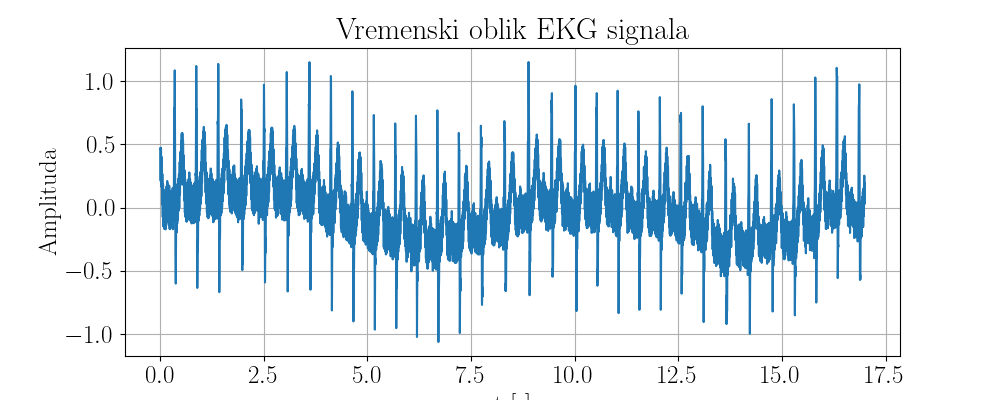

In [3]:
#Uvoženje ekg signala i prikazivanje

ekg_sig = sio.loadmat("dz2_signali/ecg_corrupted.mat")
fs = 360
Ts = 1/fs

ekg = ekg_sig["ecg_corrupted"].squeeze()

N = len(ekg)


duration = N*Ts

t = np.arange(0,duration,Ts)

plt.figure(figsize=(10, 4))
plt.plot(t, ekg)
plt.title("Vremenski oblik EKG signala")
plt.xlabel("t [s]")
plt.ylabel("Amplituda")
plt.grid(True)
plt.show()

In [4]:
#Definisanje funkcije 
def baselineDriftFilter(fs, fa, fp, Aa, Ap):

    wa = 2 * np.pi * fa
    wp = 2 * np.pi * fp

    D =  (10**(0.1*Aa)-1)/(10**(0.1*Ap)-1) 
    k = wa/wp
    N = math.ceil( math.acosh(math.sqrt(D))/math.acosh(1/k) )

    z, p, k = signal.cheb2ap(N, Aa)

    an = np.array(np.poly(p))
    bn = k*np.array(np.poly(z))

    if an.shape == ():
        an = np.array([an])
    if bn.shape == ():
        bn = np.array([bn])

    b, a = signal.lp2hp(bn, an, wa)
    bd,ad = signal.bilinear(b, a, fs)

    return bd, ad

In [5]:
#Definisaanje druge funckije
def powerLineNoiseFilter(fs, fc, Aa, Ap):

    Ts = 1/fs

    fp1 = (fc - 2) /fs
    fp2 = (fc + 2) /fs
    fa1 = (fc - 0.5) /fs
    fa2 = (fc + 0.5) /fs

    Wa1 = fa1*2*np.pi 
    Wp1 = fp1*2*np.pi 
    Wp2 = fp2*2*np.pi 
    Wa2 = fa2*2*np.pi 

    wa1 = 2/Ts*math.tan(Wa1/2)
    wp1 = 2/Ts*math.tan(Wp1/2)
    wp2 = 2/Ts*math.tan(Wp2/2)
    wa2 = 2/Ts*math.tan(Wa2/2)

    wpN = 1
    
    w0 = np.sqrt(wp1*wp2)
    B = (wp2 - wp1)/wpN

    if (wa1 > w0**2/wa2):
        print(wa2)
        wa2 = w0**2/wa1
        print(wa2)


    waN = (wa2**2 - w0**2)/(B*wa2)

    D =  (10**(0.1*Aa)-1)/(10**(0.1*Ap)-1) 
    k = waN/wpN
    N = math.ceil( math.acosh(math.sqrt(D))/math.acosh(1/k) )

    z, p, k = signal.cheb2ap(N, Aa)

    an = np.array(np.poly(p))
    bn = k*np.array(np.poly(z))

    if an.shape == ():
        an = np.array([an])
    if bn.shape == ():
        bn = np.array([bn])

    b, a = signal.lp2bs(bn, an, w0, B)
    
    bd,ad = signal.bilinear(b, a, fs)

    return bd, ad

419.89158964582606
419.57170414985654


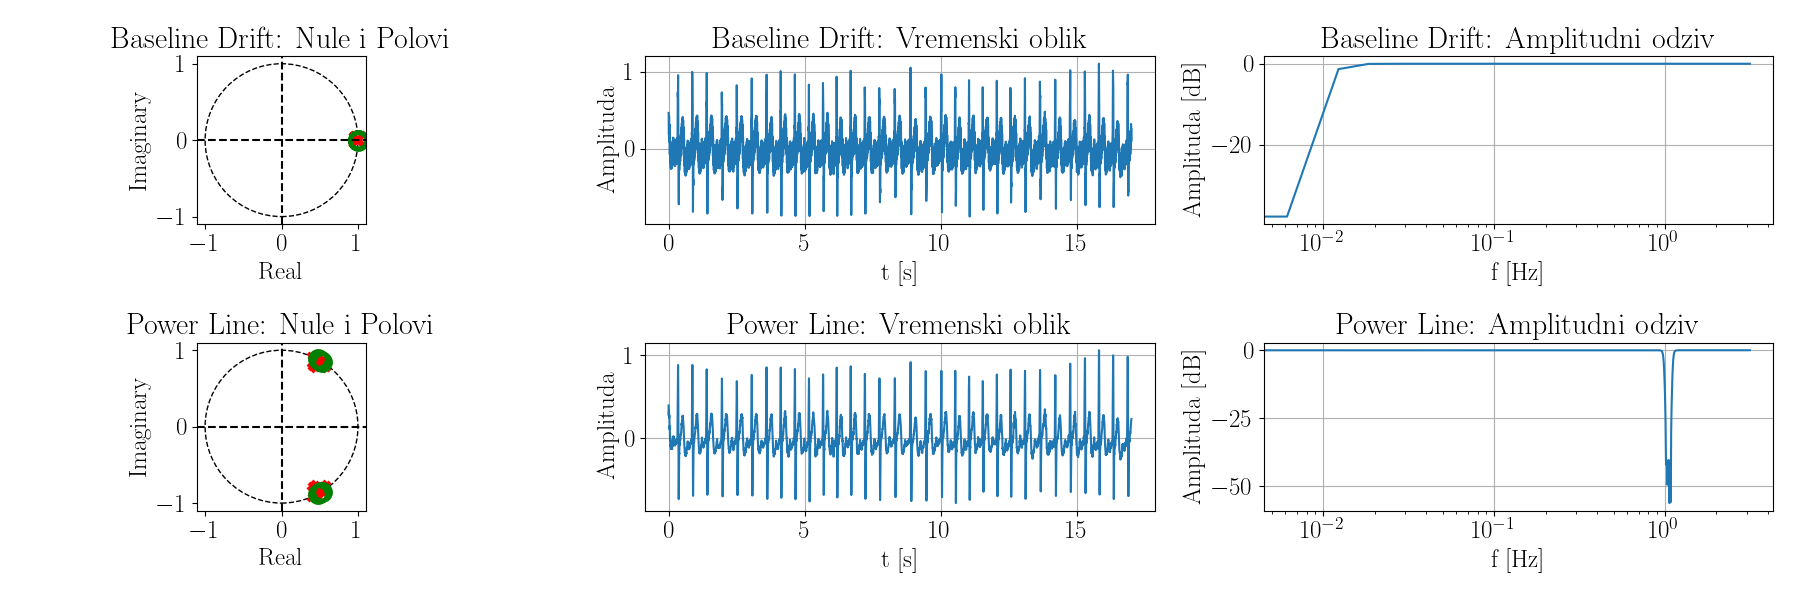

In [6]:
fig = plt.figure(figsize=(18, 6))
plt.subplots_adjust(wspace=0.4)

#Prvi deo
fa = 0.4
fp = 1
Aa = 30
Ap = 0.5

b1, a1 = baselineDriftFilter(fs, fa, fp, Aa, Ap)
ekg_f1 = signal.lfilter(b1, a1, ekg)

w, H = signal.freqz(b1, a1, worN=512)
Ha = 20 * np.log10(abs(H))  # u dB

# --- PLOT ---
ax1 = fig.add_subplot(2,3,1, aspect='equal')
zplane(b1, a1, ax1)
ax1.set_title('Baseline Drift: Nule i Polovi')

ax2 = fig.add_subplot(2,3,2)
ax2.plot(t, ekg_f1)
ax2.set_title("Baseline Drift: Vremenski oblik")
ax2.set_xlabel("t [s]")
ax2.set_ylabel("Amplituda")
ax2.grid(True)

ax3 = fig.add_subplot(2,3,3)
ax3.semilogx(w, Ha)
ax3.set_title("Baseline Drift: Amplitudni odziv")
ax3.set_xlabel("f [Hz]")
ax3.set_ylabel("Amplituda [dB]")
ax3.grid(True)

#ax3.add_patch(mpl.patches.Polygon([[0, -Aa ], [fa, -Aa], [fa, -Aa+2], [0, -Aa+2]], closed=True,
#                                  fill=False, hatch='////', color = 'red'))
# Pass band lim
#ax3.add_patch(mpl.patches.Polygon([[fp, -Ap-2 ], [fp, -Ap-2], [fp, -Ap], [fp, -Ap]], closed=True,
#                                  fill=False, hatch='////', color = 'red'))

# Drugi deo
fc = 60
Aa = 40
Ap = 0.5

b2, a2 = powerLineNoiseFilter(fs, fc, Aa, Ap)
ekg_f2 = signal.lfilter(b2, a2, ekg_f1)

w, H = signal.freqz(b2, a2, worN=512)
Ha = 20 * np.log10(abs(H))  # u dB

# --- PLOT ---
ax4 = fig.add_subplot(2,3,4, aspect='equal')
zplane(b2, a2, ax4)
ax4.set_title('Power Line: Nule i Polovi')

ax5 = fig.add_subplot(2,3,5)
ax5.plot(t, ekg_f2)
ax5.set_title("Power Line: Vremenski oblik")
ax5.set_xlabel("t [s]")
ax5.set_ylabel("Amplituda")
ax5.grid(True)

ax6 = fig.add_subplot(2,3,6)
ax6.semilogx(w, Ha)
ax6.set_title("Power Line: Amplitudni odziv")
ax6.set_xlabel("f [Hz]")
ax6.set_ylabel("Amplituda [dB]")
ax6.grid(True)

plt.tight_layout()
plt.show()




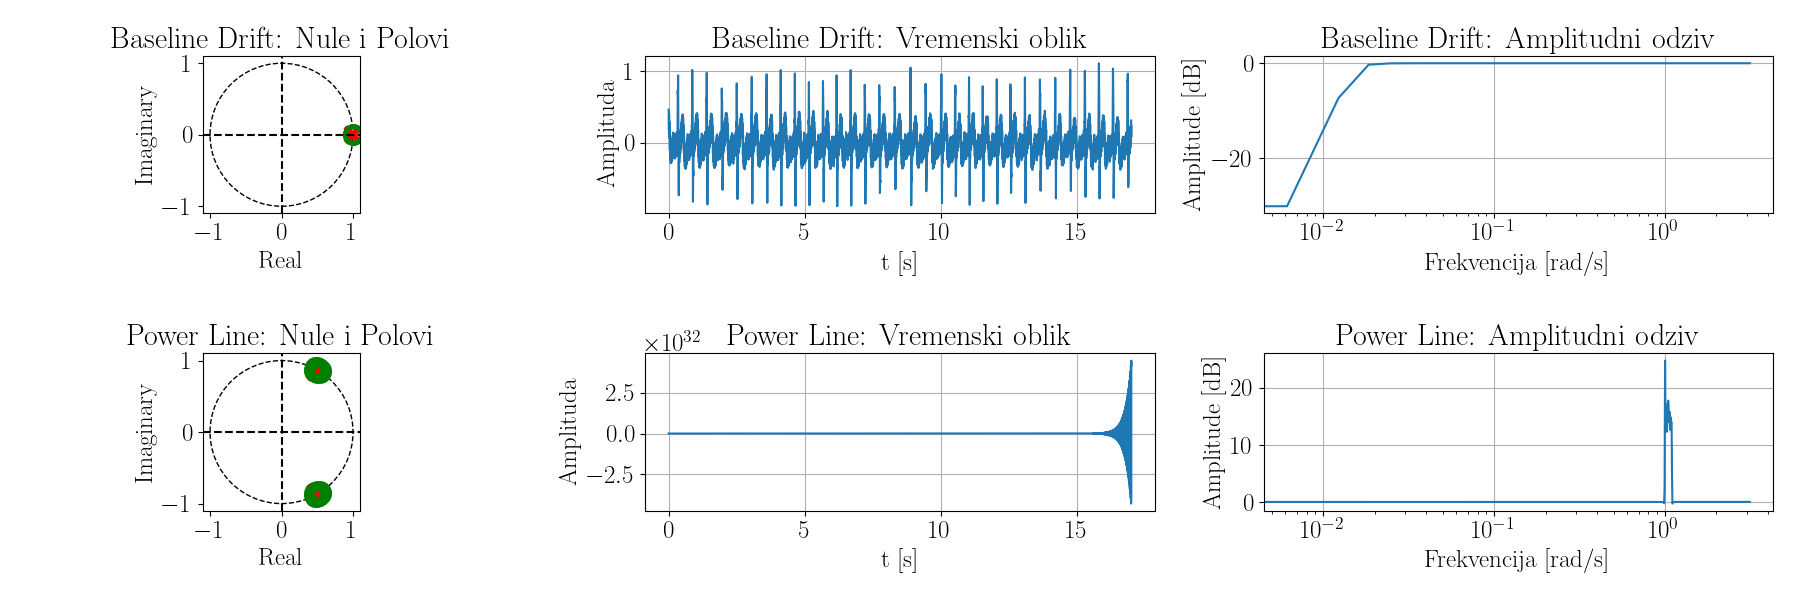

In [7]:
#Ovaj deo je za implementiraane SCIPY funkcije


fig = plt.figure(figsize=(18, 6))
plt.subplots_adjust(wspace=0.4)

# Prvi deo
fa = 0.4
fp = 1
Aa = 30
Ap = 0.5

b1, a1 = signal.iirdesign(wp=fp, ws=fa, gpass=Ap, gstop=Aa,
                              ftype='cheby2', fs=fs)
ekg_f1 = signal.lfilter(b1, a1, ekg)

# Frekvencijski odziv
w, H = signal.freqz(b1, a1, worN=512)
Ha = 20 * np.log10(abs(H))  # u dB

# --- PLOT ---
ax1 = fig.add_subplot(2,3,1, aspect='equal')
zplane(b1, a1, ax1)
ax1.set_title('Baseline Drift: Nule i Polovi')

ax2 = fig.add_subplot(2,3,2)
ax2.plot(t, ekg_f1)
ax2.set_title("Baseline Drift: Vremenski oblik")
ax2.set_xlabel("t [s]")
ax2.set_ylabel("Amplituda")
ax2.grid(True)

ax3 = fig.add_subplot(2,3,3)
ax3.semilogx(w, Ha)
ax3.set_title("Baseline Drift: Amplitudni odziv")
ax3.set_xlabel("Frekvencija [rad/s]")
ax3.set_ylabel("Amplitude [dB]")
ax3.grid(True)


#Drugi deo
Aa = 40
Ap = 0.5
fc = 60

bw = 4  # ±2 Hz
f1 = fc - bw/2
f2 = fc + bw/2

# Passband i stopband za notch
wp = [f1-0.5, f2+0.5]  # passband krajevi
ws = [f1, f2]          # stopband (notch)

b2, a2 = signal.iirdesign(wp=wp, ws=ws, gpass=Ap, gstop=Aa,
                                    ftype='cheby2', fs=fs)
ekg_f2 = signal.lfilter(b2, a2, ekg_f1)

w, H = signal.freqz(b2, a2, worN=512)
Ha = 20 * np.log10(abs(H))  # u dB

# --- PLOT  ---
ax4 = fig.add_subplot(2,3,4, aspect='equal')
zplane(b2, a2, ax4)
ax4.set_title('Power Line: Nule i Polovi')

ax5 = fig.add_subplot(2,3,5)
ax5.plot(t, ekg_f2)
ax5.set_title("Power Line: Vremenski oblik")
ax5.set_xlabel("t [s]")
ax5.set_ylabel("Amplituda")
ax5.grid(True)

ax6 = fig.add_subplot(2,3,6)
ax6.semilogx(w, Ha)
ax6.set_title("Power Line: Amplitudni odziv")
ax6.set_xlabel("Frekvencija [rad/s]")
ax6.set_ylabel("Amplitude [dB]")
ax6.grid(True)

plt.tight_layout()
plt.show()





Iz nekog razloga integrisana funkcija prepozaje Band Pass filter

# Deo 2.

In [8]:
def forceAspect(ax, aspect=1):
    im = ax.get_images()
    extent =  im[0].get_extent()
    ax.set_aspect(abs((extent[1]-extent[0])/(extent[3]-extent[2]))/aspect)

In [9]:
def dosSpectrogram(x, fs, window, noverlap, nfft, fMaxShow): 
    
    Nx = len(x)                                                 
    n = np.arange(Nx)                                           
    t = n/fs                                                    
    one_sided = True                                            
    for i in x:                                                 
        if np.imag(i) != 0:
            one_sided = False                                
    
    S = [np.abs(fft(x[i:i+nfft]*window,nfft)) for i in range(0, Nx - nfft, nfft - noverlap)] 
    f = np.arange(nfft)*fs/nfft 
    
    if one_sided == False:
        S = fft.fftshift(S)
        f = (np.arange(nfft)-nfft//2)*fs/nfft                  
    
    S = np.array(S).T 
    
    fMaxIndex = nfft*fMaxShow//fs
    fMaxIndex = round(fMaxIndex)
    return f, t, S[:][:fMaxIndex]

In [11]:
fs, x = wavfile.read("dz2_signali/sound_corrupted.wav")

IPython.display.display(IPython.display.Audio(x, rate=fs))

48000


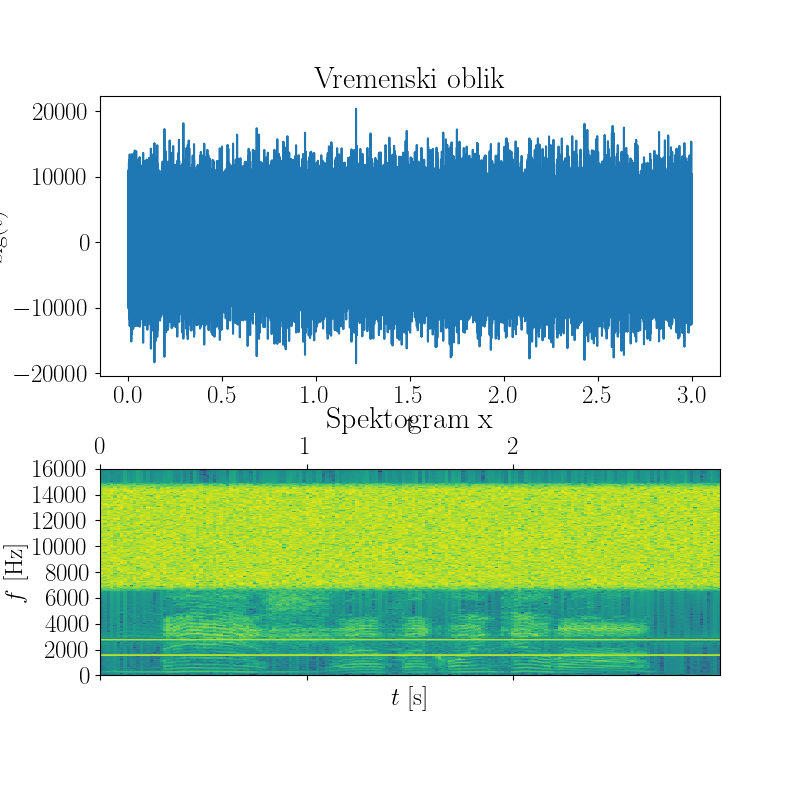

In [12]:
Nwin = 1024
window = windows.hamming(Nwin)
NFFT = Nwin

fMaxShow = 16000

t = np.arange(len(x))/fs

fMaxIndex = NFFT*fMaxShow//fs

f, t, S = dosSpectrogram(x, fs,window, Nwin//4,NFFT,fMaxShow)

fig, ax = plt.subplots(2, 1, figsize=(8, 8))

ax[0].plot(t,x)
ax[0].set(title="Vremenski oblik", ylabel="sig(t)",xlabel="t")

ax[1].matshow(20*np.log10(abs(S[:][:fMaxIndex])), extent=[min(t), max(t), min(f), fMaxShow], origin='lower')
forceAspect(ax[1], 3)
ax[1].set(title="Spektogram x")
ax[1].set_xlabel('$t$ [s]')
ax[1].set_ylabel('$f$ [Hz]');

print(fs)

Po spektrogramu vidimo vevlike smetnje na f: 1400-1700 U 2550-2900, to treba da isfiltriramo, potrebni su nam 2 filtra nepropusnikaa opsega. Vidimo i mali sum na frekvencijama 150-300, mada to samo na prvi pogled pa cu videti ksanije da ali je potrebno da se isfiltrira. Sve preko 6k Hz bi mogli da isfriltriramo ali me mrzi da pravim Vf tako da cu samo iskoristiti Bs

## Signal iz 1. tacke

In [13]:
def firDirect(h, x, state = None):
    M = len(h)
    if state == None:
        delayLine = np.zeros(M)
    else:
        delayLine = state
    
    y = np.zeros(len(x))
    for n in range(len(x)):
        delayLine[1:] = delayLine[:M-1]
        delayLine[0] = x[n]
        for m in range(M):
            y[n] += h[m]*delayLine[m]
    
    return y

In [14]:
def fir_vf(fp, fa, Ap, Aa):

    Wa = 2 * np.pi * fa 
    Wp = 2 * np.pi * fp 
    
    Bt = Wp - Wa
    
    # Delta
    delta_p = (10**(0.05*Ap)-1)/(10**(0.05*Ap)+1)
    delta_a = 10**(-0.05*Aa)
    
    delta = min([delta_p, delta_a])
    
    # Alpha_a
    if delta < delta_a:
        AaSpec = -20*np.log10(delta)
    else:
        AaSpec = Aa
        
    # Beta
    beta = 0;
    if AaSpec < 21:
        beta = 0
    elif AaSpec <= 50:
        beta = 0.5842*(AaSpec-21)**0.4 + 0.07886*(AaSpec-21)
    else:
        beta = 0.1102*(AaSpec-8.7)
    
    # Filter order
    if AaSpec <= 21:
        D = 0.9222
    else:
        D = (AaSpec-7.95)/14.36
    M = int(np.ceil(2*np.pi*D/Bt + 1))
    N = M - 1
    
    w = windows.kaiser(M, beta)
    
    Wc = (Wa + Wp)/2
    
    na = np.arange(-N/2, N/2+1, 1)
    n = np.arange(N+1)
    
    hID = np.zeros(N+1)
    '''
    if N % 2 == 0:
        na = np.delete(na, N//2) # remove index 0
        hID[n != N//2] = np.sin(Wc*na)/(na*np.pi)
        hID[N//2] = Wc/np.pi # lim in na->0
    else:
        hID = np.sin(Wc*na)/(na*np.pi) '''
    if N % 2 == 0:
        na = np.delete(na, N//2)
        hID[n != N//2] = (np.sin(np.pi*na) - np.sin(Wc*na)) / (np.pi*na)
        hID[N//2] = 1 - Wc/np.pi
    else:
        hID = (np.sin(np.pi*na) - np.sin(Wc*na)) / (np.pi*na)


    h = hID * w

    W, H = signal.freqz(h, 1, worN = 16000)

    return n,h,W,H

In [15]:
def fir_bs(fa1, fa2, fp1, fp2,fs, Ap, Aa):
    # Pretvori frekvencije u radijane
    Wa1 = fa1 * 2 * np.pi /fs
    Wp1 = fp1 * 2 * np.pi /fs 
    Wp2 = fp2 * 2 * np.pi /fs
    Wa2 = fa2 * 2 * np.pi /fs
    

    # Transition width
    Bt = min([Wa1 - Wp1, Wp2 - Wa2])
    
    # Srednje granice prelaznih opsega
    Wc1 = (Wa1 + Wp1) / 2
    Wc2 = (Wa2 + Wp2) / 2
    
    # Delta vrednosti za prolazni i zaporni opseg
    delta_p = (10**(0.05*Ap) - 1) / (10**(0.05*Ap) + 1)
    delta_a = 10**(-0.05*Aa)
    delta = min([delta_p, delta_a])
    
    # Efektivno Aa
    AaSpec = -20 * np.log10(delta)
    
    # Kaiser parametar β
    if AaSpec < 21:
        beta = 0
    elif AaSpec <= 50:
        beta = 0.5842 * (AaSpec - 21)**0.4 + 0.07886 * (AaSpec - 21)
    else:
        beta = 0.1102 * (AaSpec - 8.7)

    # Parametar D
    if AaSpec <= 21:
        D = 0.9222
    else:
        D = (AaSpec - 7.95) / 14.36

    # Početni red
    M = int(np.ceil(2 * np.pi * D / Bt + 1))
    N = M - 1
    Norig = N

    filterFitsInSpecs = False
    first = True
    numPoints = 1024  # rezolucija frekvencijskog odziva
    
    # Iterativno povećavaj red dok filter ne zadovolji specifikacije
    while not filterFitsInSpecs:
        w = windows.kaiser(N + 1, beta)
        na = np.arange(-N/2, N/2 + 1, 1)
        n = np.arange(N + 1)
        
        hID = np.zeros(N + 1)
        if N % 2 == 0:
            na = np.delete(na, N//2)
            hID[n != N//2] = np.sin(np.pi*na)/(np.pi*na) - (np.sin(Wc2*na)/(np.pi*na) - np.sin(Wc1*na)/(np.pi*na))
            hID[N//2] = 1 - (Wc2 - Wc1)/np.pi
        else:
            hID = np.sin(np.pi*na)/(np.pi*na) - (np.sin(Wc2*na)/(np.pi*na) - np.sin(Wc1*na)/(np.pi*na))
        
        # Konačan impulsni odziv
        h = hID * w

        # Frekvencijski odziv
        W, H = signal.freqz(h, 1, worN=numPoints)
        Hdb = 20 * np.log10(abs(H) + 1e-12)  # u dB

        # Indeksi opsega
        DeltaW = np.pi / numPoints
        kSB1 = int(np.ceil(Wp1 / DeltaW))
        kPB1 = int(np.floor(Wa1 / DeltaW))
        kPB2 = int(np.ceil(Wa2 / DeltaW))
        kSB2 = int(np.floor(Wp2 / DeltaW))

        # Provera specifikacija
        if np.all(Hdb[:kSB1] > -Ap) and np.all(Hdb[kPB1:kPB2] < -Aa) and \
            np.all(Hdb[kSB2:] > -Ap):
            filterFitsInSpecs = True
        else:
            N += 1
            # sigurnosna zaštita – ako je red prevelik
            if N > 5000:
                print("Filter ne može da ispuni specifikacije do N=5000.")
                break

        #print(np.all(Hdb[:kSB1] > -Ap),np.all(Hdb[kPB1:kPB2] < -Aa),np.all(Hdb[kSB2:] > -Ap))
        #print(Hdb[kSB1], '>-ap')
        #print(Hdb[kPB1],Hdb[kPB2], '<-aa')
        #print(Hdb[kSB2], '>-ap')
        

    return n, h, W, H


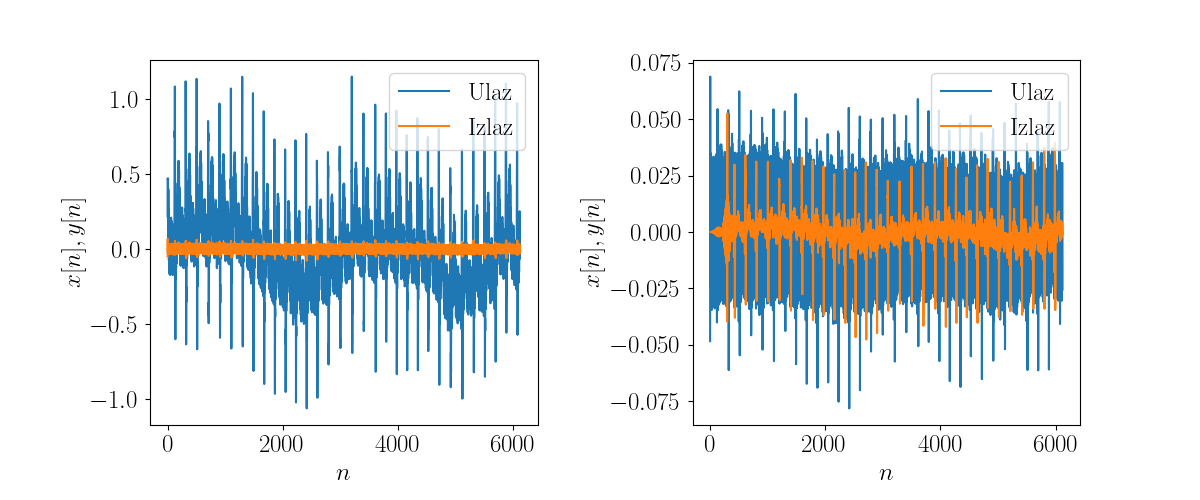

In [16]:
ekg_sig = sio.loadmat("dz2_signali/ecg_corrupted.mat")
fs = 360
Ts = 1/fs

ekg = ekg_sig["ecg_corrupted"].squeeze()

N = len(ekg)

fig = plt.figure(figsize = (12,5))
plt.subplots_adjust(bottom=0.15, wspace = 0.4)

#Prvi deo
fa = 0.4
fp = 1
Aa = 30
Ap = 0.5

n1, h1, W1, H1 = fir_vf(fp,fa,Ap,Aa)

y1 = firDirect(h1,ekg)

ax1 = fig.add_subplot(1,2,1)
ax1.plot(np.arange(len(ekg)), ekg, label = 'Ulaz',)
ax1.plot(np.arange(len(y1)), y1, label = 'Izlaz')
ax1.set_xlabel(r'$n$')
ax1.set_ylabel(r'$x[n], y[n]$')
ax1.legend(loc = 'upper right');

# Drugi deo
fc = 60
Aa = 40
Ap = 0.5

fp1 = (fc - 2) #/fs
fp2 = (fc + 2) #/fs
fa1 = (fc - 0.5) #/fs
fa2 = (fc + 0.5) #/fs

n2, h2, W2, H2 = fir_bs(fa1,fa2,fp1,fp2,fs, Ap, Aa)

y2 = firDirect(h2, y1)

ax2 = fig.add_subplot(1,2,2)
ax2.plot(np.arange(len(y1)), y1, label = 'Ulaz')
ax2.plot(np.arange(len(y2)), y2, label = 'Izlaz')
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'$x[n], y[n]$')
ax2.legend(loc = 'upper right');

### Deluje mi da nije dobro

In [ ]:
#Sredjujemo zvucni signal
fs, x = wavfile.read("dz2_signali/sound_corrupted.wav")

Aa = 12
Ap = 0.5

fp1=1250
fa1=1400
fa2=1650
fp2=1800

n1,h1,W1,H1 = fir_bs(fa1, fa2, fp1, fp2,fs, Ap, Aa)
print(len(h1))
fp1=2400
fa1=2550
fa2=2850
fp2=3000
print('uradio y1')

n2,h2,W2,H2 = fir_bs(fa1, fa2, fp1, fp2,fs, Ap, Aa)
print(len(h2))
print('uradio y2')

fp1=5800
fa1=6000
fa2=14800
fp2=15000

n3,h3,W3,H3 = fir_bs(fa1, fa2, fp1, fp2,fs, Ap, Aa)
print(len(h3))
print('uradio y3')
y1 = firDirect(h1, x)
print('uradio firdir y1')

y2 = firDirect(h2, y1)
print('uradio firdir y2')

y3 = firDirect(h3, y2)
print('uradio firdir y3')

Nwin = 1024//2
window = windows.hamming(Nwin)
NFFT = Nwin

fMaxShow = 16000

print(fs)

t = np.arange(len(y3))/fs

fMaxIndex = NFFT*fMaxShow//fs

f1, t1, S1 = dosSpectrogram(y3, fs,window, Nwin//4,NFFT,fMaxShow)
print('spec')

fig, ax = plt.subplots(2, 1, figsize=(8, 8))

ax[0].plot(t,y3)
ax[0].set(title="Vremenski oblik", ylabel="sig(t)",xlabel="t")

ax[1].matshow(20*np.log10(abs(S1[:][:fMaxIndex])), extent=[min(t1), max(t1), min(f1), fMaxShow], origin='lower')
forceAspect(ax[1], 3)
ax[1].set(title="Spektogram x")
ax[1].set_xlabel('$t$ [s]')
ax[1].set_ylabel('$f$ [Hz]');

IPython.display.display(IPython.display.Audio(y3, rate=fs))

601
uradio y1
511
uradio y2
385
uradio y3


In [ ]:

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].semilogx(W1, H1)
axes[0].set_title("Filter 1: Amplitudni odziv")
axes[0].set_xlabel("f [Hz]")
axes[0].set_ylabel("Amplituda [dB]")
axes[0].grid(True, which='both', linestyle=':')


axes[1].semilogx(W2, H2)
axes[1].set_title("Filter 2: Amplitudni odziv")
axes[1].set_xlabel("f [Hz]")
axes[1].set_ylabel("Amplituda [dB]")
axes[1].grid(True, which='both', linestyle=':')


axes[2].semilogx(W3, H3)
axes[2].set_title("Filter 3: Amplitudni odziv")
axes[2].set_xlabel("f [Hz]")
axes[2].set_ylabel("Amplituda [dB]")
axes[2].grid(True, which='both', linestyle=':')

plt.tight_layout()
plt.show()


# Deo 3.

In [ ]:
def iirDirectCan(b, a, x, state=None):
    M = max(len(a), len(b)) - 1

    if state == None:
        delayLine = np.zeros(M)
    else:
        delayLine = state

    y = np.zeros(len(x))

    for n in range(len(x)):
        x_1 = x[n]
        for i in range(1, len(a)):
            if i - 1 < M:
                x_1 -= a[i] * delayLine[i-1]
        
        y[n] = b[0] * x_1
        for i in range(1, len(b)):
            if i - 1 < M:
                y[n] += b[i] * delayLine[i-1]
                
        delayLine[1:] = delayLine[:M-1]
        delayLine[0] = x_1
        
    return y


In [ ]:
#Kradem signal iz dz1

# Signal s(t)
fs = 100
Ts = 1/fs

# Proizvoljno odredjeni broj N za odredjivanje furijeove transformacije
N = 1024
f=np.arange(N)*fs/N

# Analogni signal x(t) i deklaracija Ni i fi
f1 = 1
f2 = 3
f3 = 7

N3 = 1024

duration3 = N3*Ts

# Odabiranje u Ts na intervalima N1, N2, N3

t3 = np.arange(0, duration3, Ts)

x3 = np.cos(2*np.pi*f1*t3) + 0.5*np.cos(2*np.pi*f2*t3) + 3*np.cos(2*np.pi*f3*t3)

fa = 4
fp = 5
Aa = 30
Ap = 0.5



b, a = baselineDriftFilter(fs, fa, fp, Aa, Ap)
print(b,a)
x3_1 = signal.lfilter(b, a, x3)

x3_2 = iirDirectCan(b,a,x3)

fig = plt.figure(figsize=(18, 6))
plt.subplots_adjust(wspace=0.4)

# --- PLOT ---
ax1 = fig.add_subplot(3,1,1)
ax1.plot(t3, x3, color='steelblue', linewidth=1.8)
ax1.set_title('Vremenski oblik ulaznog signala', fontsize=13, fontweight='bold')
ax1.set_ylabel("Amplituda", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.tick_params(labelsize=10)

ax2 = fig.add_subplot(3,1,2)
ax2.plot(t3, x3_1, color='darkorange', linewidth=1.8)
ax2.set_title("Signal kroz lfilter", fontsize=13, fontweight='bold')
ax2.set_xlabel("t [s]", fontsize=11)
ax2.set_ylabel("Amplituda", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.tick_params(labelsize=10)

ax3 = fig.add_subplot(3,1,3)
ax3.plot(t3, x3_2, color='forestgreen', linewidth=1.8)
ax3.set_title("Signal kroz iirDirect", fontsize=13, fontweight='bold')
ax3.set_xlabel("t [s]", fontsize=11)
ax3.set_ylabel("Amplituda", fontsize=11)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.tick_params(labelsize=10)

plt.tight_layout(pad=2.0)
plt.show()

